# Phase 2 EDA: NASA CMAPSS FD001

**Goal:** Identify informative vs near-constant sensors, visualise degradation patterns, characterise the RUL distribution, and justify capping at 125 cycles.

**Dataset:** 100 turbofan engines, single operating condition (sea-level cruise), HPC degradation fault mode (FD001).

**Outputs:** Six PNG figures saved to `reports/figures/`.

In [1]:
import sys
import warnings
from pathlib import Path

# Resolve project root (one level up from notebooks/) and add to sys.path
PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from rul_prediction.components.data_ingestion import DataIngestion
from rul_prediction.config.configuration import load_config

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

# Physical sensor names from reports/sensor_reference.md
SENSOR_LABELS = {
    'sensor_1':  'T2 (fan inlet temp, Â°R)',
    'sensor_2':  'T24 (LPC outlet temp, Â°R)',
    'sensor_3':  'T30 (HPC outlet temp, Â°R)',
    'sensor_4':  'T50 (LPT outlet temp, Â°R)',
    'sensor_5':  'P2 (fan inlet pressure, psia)',
    'sensor_6':  'P15 (bypass-duct pressure, psia)',
    'sensor_7':  'P30 (HPC outlet pressure, psia)',
    'sensor_8':  'Nf (fan speed, rpm)',
    'sensor_9':  'Nc (core speed, rpm)',
    'sensor_10': 'epr (engine pressure ratio)',
    'sensor_11': 'Ps30 (HPC static pressure, psia)',
    'sensor_12': 'phi (fuel flow / Ps30, pps/psi)',
    'sensor_13': 'NRf (corrected fan speed, rpm)',
    'sensor_14': 'NRc (corrected core speed, rpm)',
    'sensor_15': 'BPR (bypass ratio)',
    'sensor_16': 'farB (burner fuel-air ratio)',
    'sensor_17': 'htBleed (bleed enthalpy)',
    'sensor_18': 'Nf_dmd (demanded fan speed, rpm)',
    'sensor_19': 'PCNfR_dmd (demanded corrected fan speed, rpm)',
    'sensor_20': 'W31 (HPT coolant bleed, lbm/s)',
    'sensor_21': 'W32 (LPT coolant bleed, lbm/s)',
}

In [2]:
cfg = load_config(config_path=str(PROJECT_ROOT / 'configs' / 'config.yaml'))
RUL_CAP = cfg['dataset']['rul_cap']

FIGURES_DIR = PROJECT_ROOT / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f'RUL cap: {RUL_CAP} | Figures -> {FIGURES_DIR}')

[2026-07-06 01:32:43,519] INFO     rul_prediction.config.configuration - Loading config from C:\Users\Satyam Mishra\OneDrive\Desktop\RUL aircraft engine AI project\configs\config.yaml


RUL cap: 125 | Figures -> C:\Users\Satyam Mishra\OneDrive\Desktop\RUL aircraft engine AI project\reports\figures


In [3]:
ingestion = DataIngestion(
    raw_data_dir=str(PROJECT_ROOT / 'data' / 'raw'), subset='FD001'
)
train_df, test_df, test_rul_df = ingestion.load_all()

SENSOR_COLS = [c for c in train_df.columns if c.startswith('sensor_')]
print('Train:', train_df.shape, '| Test:', test_df.shape, '| RUL:', test_rul_df.shape)

[2026-07-06 01:32:43,553] INFO     rul_prediction.components.data_ingestion - Reading raw file: C:\Users\Satyam Mishra\OneDrive\Desktop\RUL aircraft engine AI project\data\raw\FD001\train_FD001.txt


[2026-07-06 01:32:43,735] INFO     rul_prediction.components.data_ingestion - Loaded train_FD001: 20631 rows, 100 engines


[2026-07-06 01:32:43,735] INFO     rul_prediction.components.data_ingestion - Reading raw file: C:\Users\Satyam Mishra\OneDrive\Desktop\RUL aircraft engine AI project\data\raw\FD001\test_FD001.txt


[2026-07-06 01:32:43,855] INFO     rul_prediction.components.data_ingestion - Loaded test_FD001: 13096 rows, 100 engines


[2026-07-06 01:32:43,856] INFO     rul_prediction.components.data_ingestion - Reading test RUL file: C:\Users\Satyam Mishra\OneDrive\Desktop\RUL aircraft engine AI project\data\raw\FD001\RUL_FD001.txt


Train: (20631, 27) | Test: (13096, 26) | RUL: (100, 1)


## 1. Missing Value Check

In [4]:
missing = train_df.isnull().sum()
print('Columns with missing values:')
print(missing[missing > 0] if missing.any() else 'None â€” dataset is complete.')

Columns with missing values:
None â€” dataset is complete.


## 2. Descriptive Statistics & Near-Constant Sensor Detection

Sensors with very low standard deviation or range carry no useful signal and should be dropped before modelling.

In [5]:
stats = train_df[SENSOR_COLS].agg(['min', 'max', 'mean', 'std']).T
stats['range'] = stats['max'] - stats['min']
stats['label'] = stats.index.map(SENSOR_LABELS)

# Empirical threshold: std < 0.01 OR range < 0.1 flags near-constant sensors
stats['near_constant'] = (stats['std'] < 0.01) | (stats['range'] < 0.1)

informative_sensors = stats[~stats['near_constant']].index.tolist()

display(stats[['min', 'max', 'mean', 'std', 'range', 'near_constant']].sort_values('std'))
print('\nNear-constant:', stats[stats['near_constant']].index.tolist())
print('Informative :', informative_sensors)

,min,max,mean,std,range,near_constant
sensor_1,518.6700,518.6700,518.670000,0.000000e+00,0.0000,True
sensor_10,1.3000,1.3000,1.300000,0.000000e+00,0.0000,True
sensor_19,100.0000,100.0000,100.000000,0.000000e+00,0.0000,True
sensor_18,2388.0000,2388.0000,2388.000000,0.000000e+00,0.0000,True
sensor_16,0.0300,0.0300,0.030000,3.469531e-18,0.0000,True
sensor_5,14.6200,14.6200,14.620000,5.329200e-15,0.0000,True
sensor_6,21.6000,21.6100,21.609803,1.388985e-03,0.0100,True
sensor_15,8.3249,8.5848,8.442146,3.750504e-02,0.2599,False
sensor_8,2387.9000,2388.5600,2388.096652,7.098548e-02,0.6600,False
sensor_13,2387.8800,2388.5600,2388.096152,7.191892e-02,0.6800,False



Near-constant: ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
Informative : ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


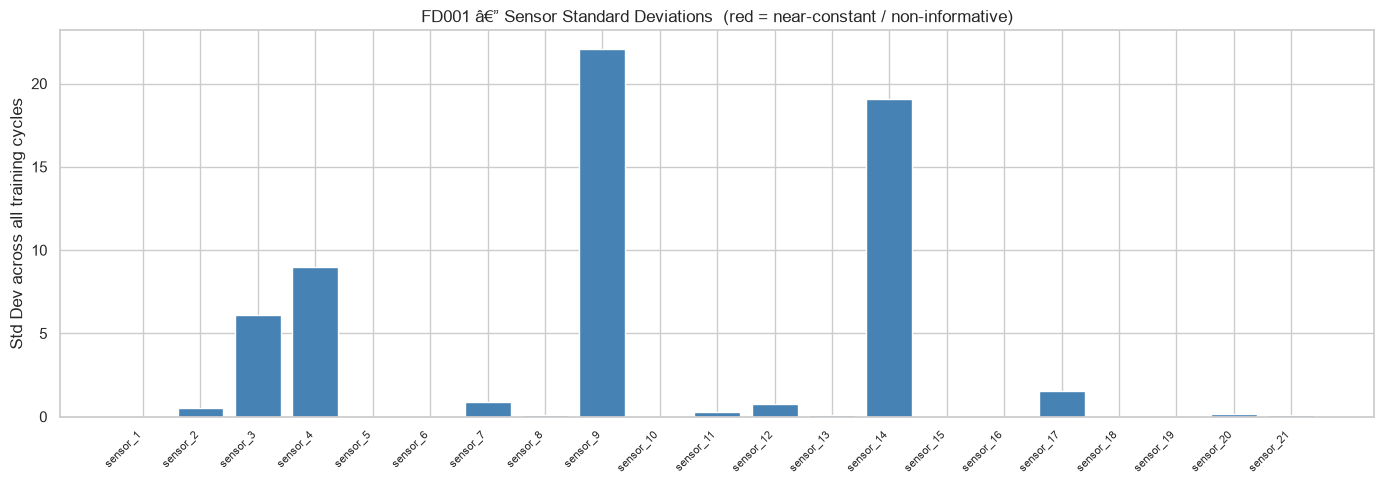

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))
colors = ['tomato' if v else 'steelblue' for v in stats['near_constant']]
ax.bar(stats.index, stats['std'], color=colors)
ax.set_xticks(range(len(stats)))
ax.set_xticklabels(stats.index, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Std Dev across all training cycles')
ax.set_title('FD001 â€” Sensor Standard Deviations  (red = near-constant / non-informative)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'sensor_std_devs.png', dpi=150)
plt.show()

## 3. Degradation Trend Visualization

Plot informative sensor readings vs `time_in_cycles` for five engines spanning short, medium, and long lifetimes to confirm which sensors show a clear monotonic trend before failure.

Sample engines (short â†’ long lifetime): [39, 63, 26, 75, 69]
Lifetimes: [128 174 199 229 362]


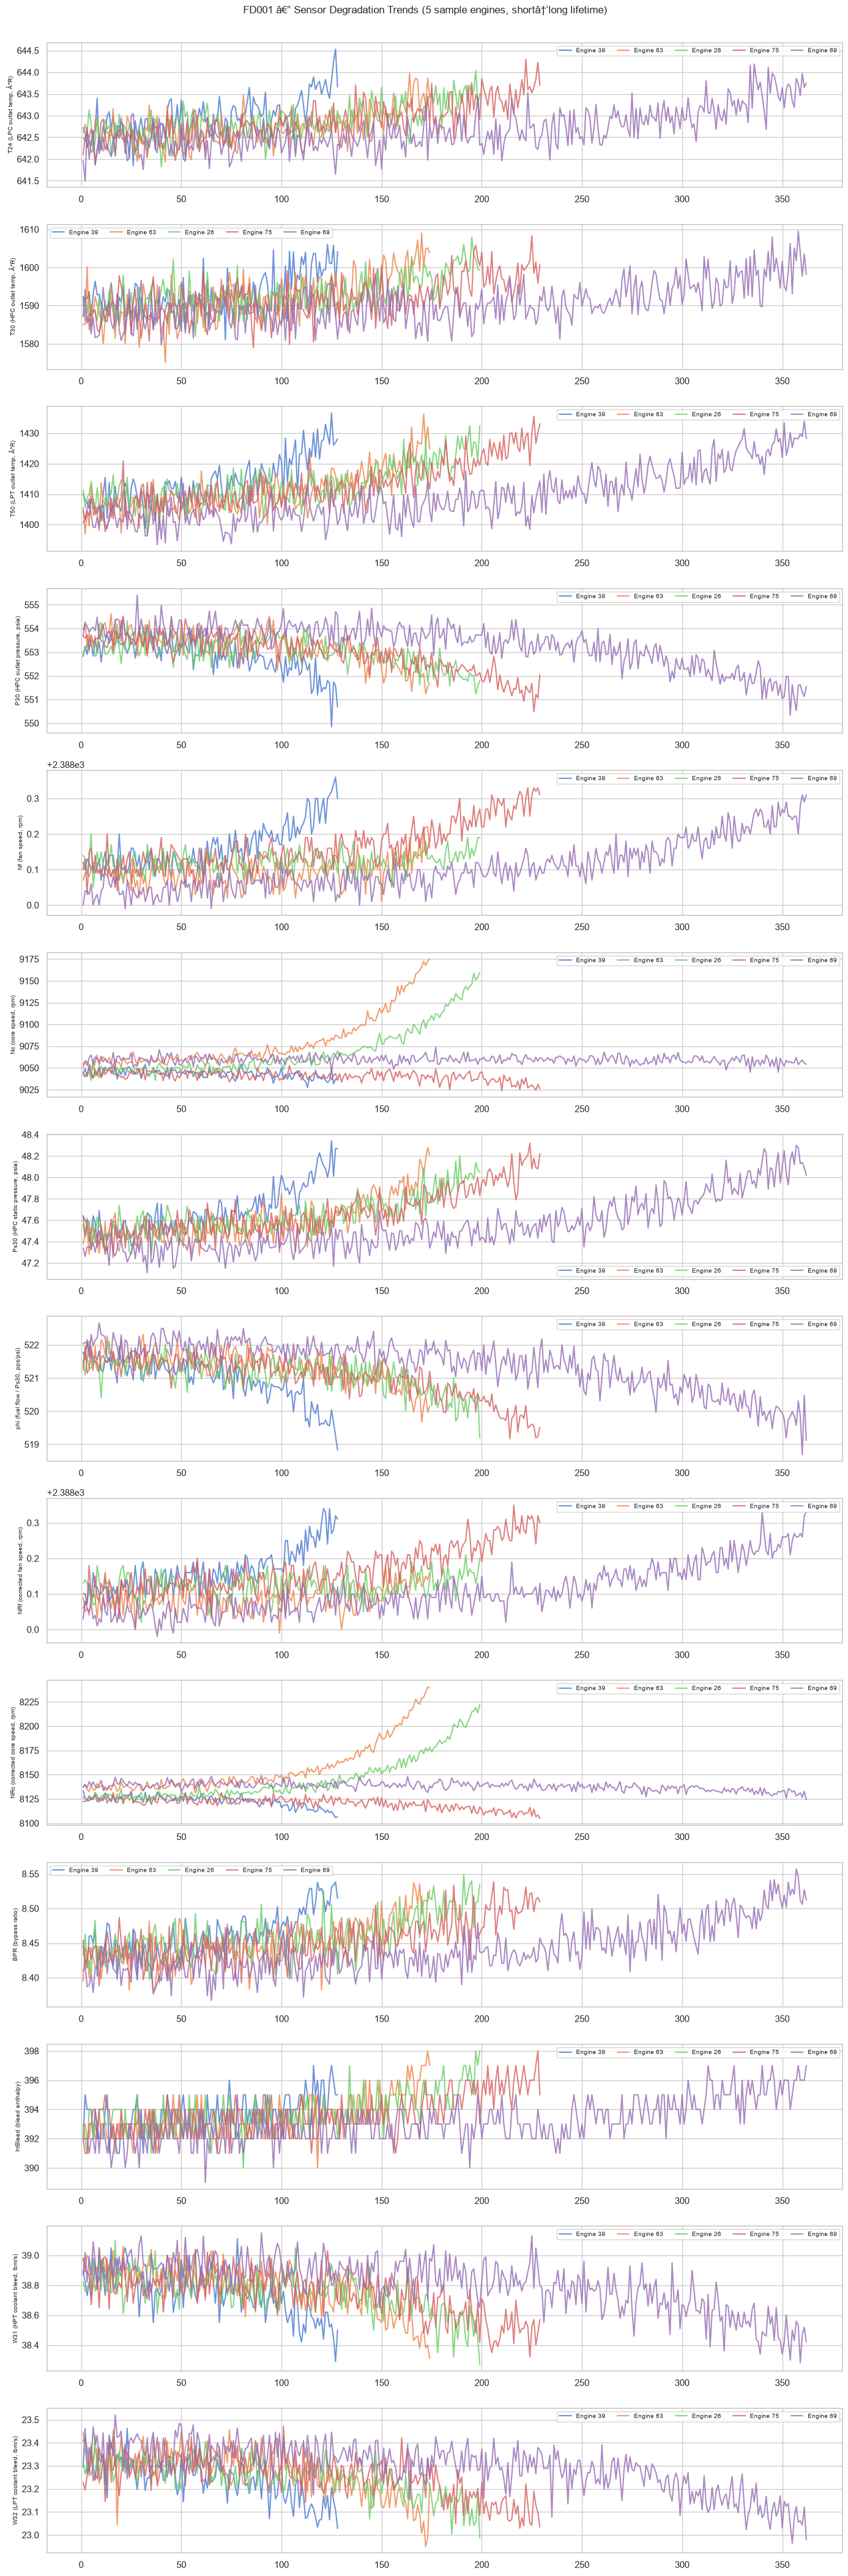

In [7]:
engine_lives = train_df.groupby('unit_number')['time_in_cycles'].max().sort_values()
sample_engines = engine_lives.iloc[[0, 24, 49, 74, 99]].index.tolist()
print('Sample engines (short â†’ long lifetime):', sample_engines)
print('Lifetimes:', engine_lives[sample_engines].values)

fig, axes = plt.subplots(
    len(informative_sensors), 1,
    figsize=(14, 3 * len(informative_sensors)),
    sharex=False, squeeze=False
)
axes = axes.flatten()

for ax, col in zip(axes, informative_sensors):
    for eng in sample_engines:
        eng_df = train_df[train_df['unit_number'] == eng]
        ax.plot(eng_df['time_in_cycles'], eng_df[col], label=f'Engine {eng}', alpha=0.8)
    ax.set_ylabel(SENSOR_LABELS[col], fontsize=7)
    ax.legend(fontsize=7, ncol=5)

plt.suptitle(
    'FD001 â€” Sensor Degradation Trends (5 sample engines, shortâ†’long lifetime)',
    fontsize=12, y=1.002
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'degradation_trends.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Correlation Analysis

Sensorâ€“sensor correlation identifies groups of redundant features. Sensorâ€“RUL correlation ranks which sensors are strongest predictors.

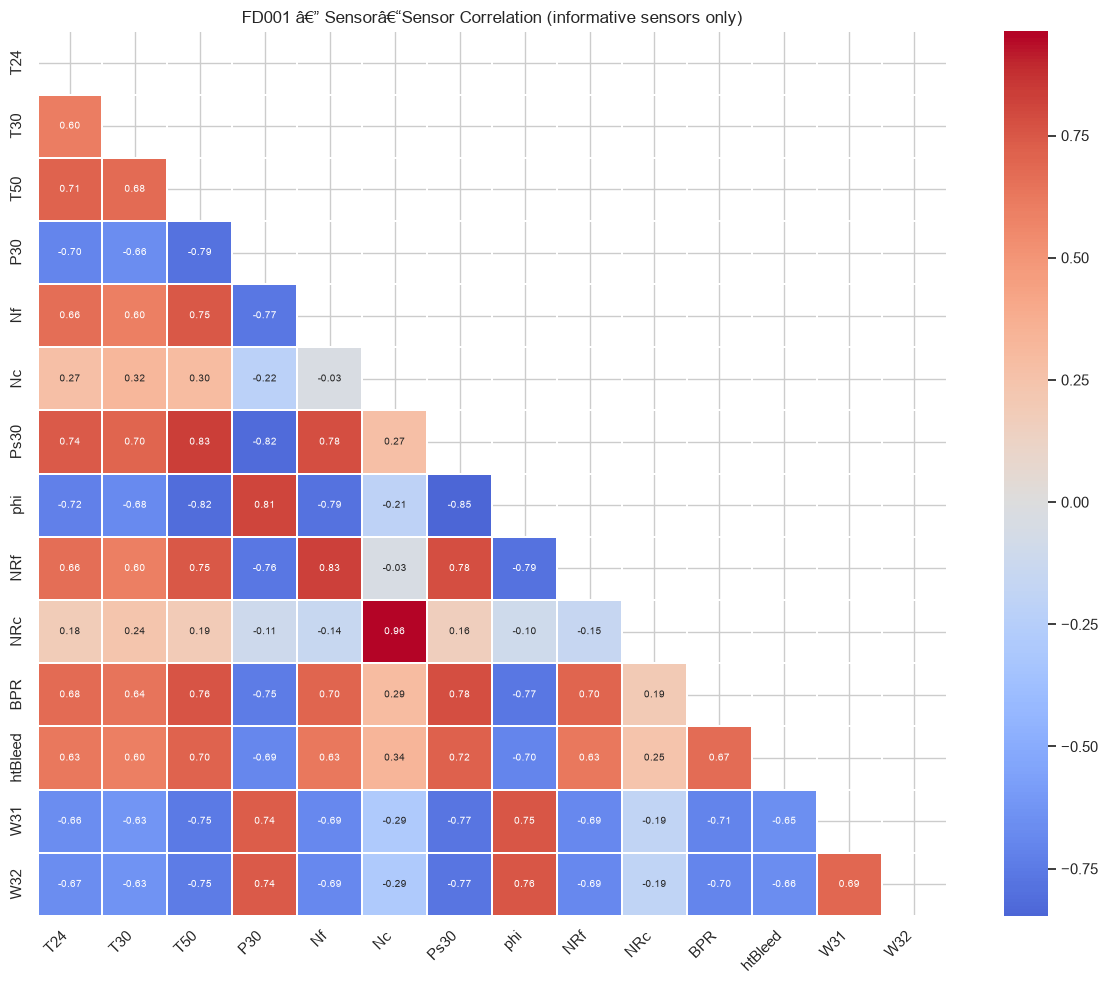

In [8]:
short_labels = [SENSOR_LABELS[c].split(' ')[0] for c in informative_sensors]
corr = train_df[informative_sensors].corr()
corr.index = short_labels
corr.columns = short_labels

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, ax=ax, linewidths=0.3, annot_kws={'size': 7}
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title('FD001 â€” Sensorâ€“Sensor Correlation (informative sensors only)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'correlation_heatmap.png', dpi=150)
plt.show()

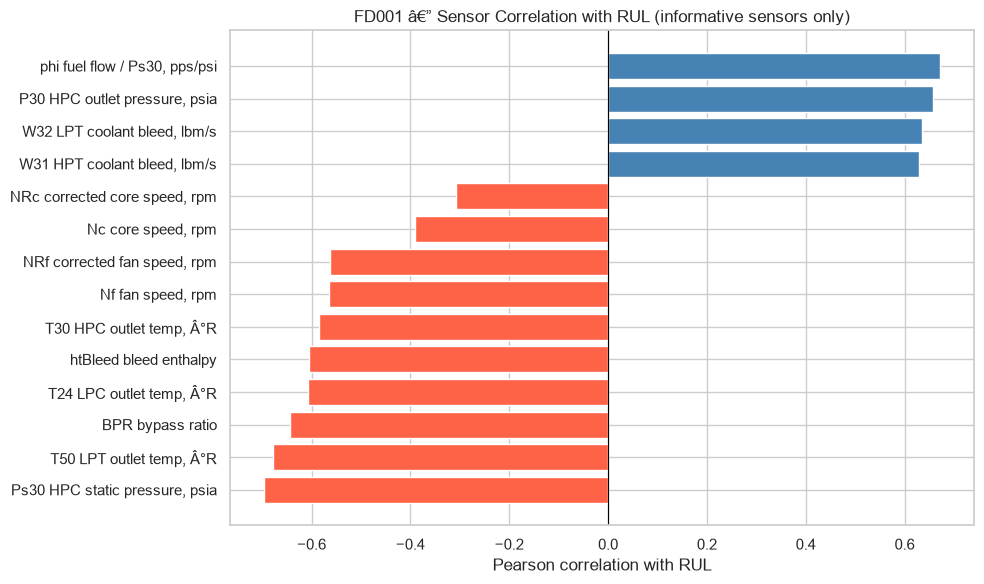

In [9]:
rul_corr = (
    train_df[informative_sensors + ['RUL']]
    .corr()['RUL']
    .drop('RUL')
    .sort_values()
)
y_labels = [SENSOR_LABELS[s].split(' ')[0] + ' ' + SENSOR_LABELS[s].split('(')[1].rstrip(')') 
            if '(' in SENSOR_LABELS[s] else SENSOR_LABELS[s]
            for s in rul_corr.index]

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['tomato' if v < 0 else 'steelblue' for v in rul_corr]
ax.barh(y_labels, rul_corr.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson correlation with RUL')
ax.set_title('FD001 â€” Sensor Correlation with RUL (informative sensors only)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'sensor_rul_correlation.png', dpi=150)
plt.show()

## 5. RUL Distribution (Training Set)

Median RUL: 103 cycles
Rows with RUL > 125: 38.9%


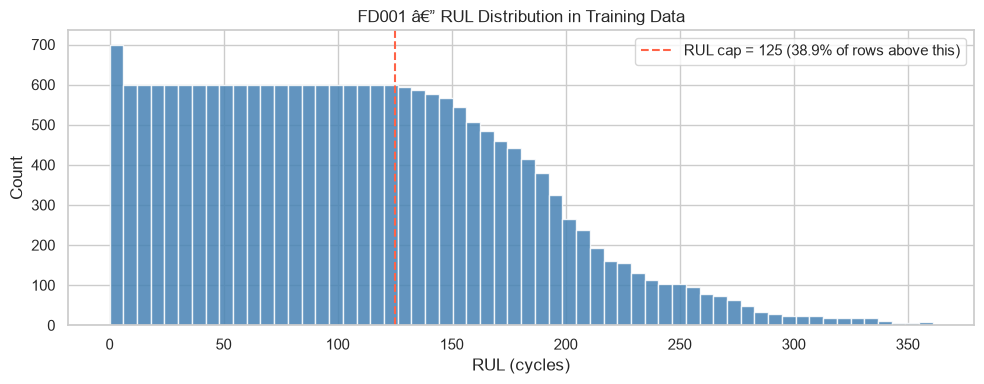

In [10]:
pct_above_cap = (train_df['RUL'] > RUL_CAP).mean() * 100
print(f'Median RUL: {train_df["RUL"].median():.0f} cycles')
print(f'Rows with RUL > {RUL_CAP}: {pct_above_cap:.1f}%')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(train_df['RUL'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(
    RUL_CAP, color='tomato', linestyle='--', linewidth=1.5,
    label=f'RUL cap = {RUL_CAP} ({pct_above_cap:.1f}% of rows above this)'
)
ax.set_xlabel('RUL (cycles)')
ax.set_ylabel('Count')
ax.set_title('FD001 â€” RUL Distribution in Training Data')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'rul_distribution.png', dpi=150)
plt.show()

## 6. RUL Capping Justification

Plot raw vs capped RUL over the longest engine's lifetime. The flat early region shows that engines operate in a stable healthy regime for many cycles before any sensor signal changes â€” the model cannot distinguish 200 from 300 cycles remaining, so capping prevents wasted model capacity on unlearnable signal.

Longest-lived engine: 69 (362 cycles)


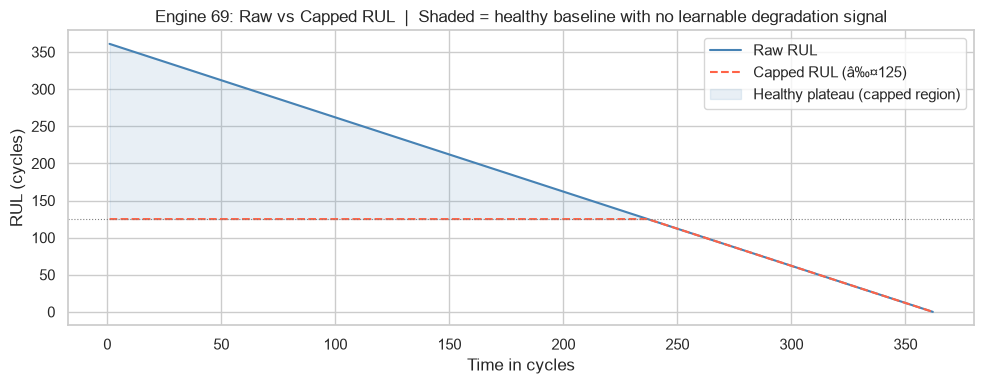

In [11]:
engine_lives = train_df.groupby('unit_number')['time_in_cycles'].max().sort_values()
longest_engine = engine_lives.idxmax()
eng_df = train_df[train_df['unit_number'] == longest_engine].copy()
print(f'Longest-lived engine: {longest_engine} ({engine_lives[longest_engine]} cycles)')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    eng_df['time_in_cycles'], eng_df['RUL'],
    label='Raw RUL', color='steelblue', linewidth=1.5
)
ax.plot(
    eng_df['time_in_cycles'], eng_df['RUL'].clip(upper=RUL_CAP),
    label=f'Capped RUL (â‰¤{RUL_CAP})', color='tomato', linewidth=1.5, linestyle='--'
)
ax.axhline(RUL_CAP, color='gray', linewidth=0.8, linestyle=':')
ax.fill_between(
    eng_df['time_in_cycles'],
    RUL_CAP, eng_df['RUL'],
    where=eng_df['RUL'] > RUL_CAP,
    alpha=0.12, color='steelblue', label='Healthy plateau (capped region)'
)
ax.set_xlabel('Time in cycles')
ax.set_ylabel('RUL (cycles)')
ax.set_title(
    f'Engine {longest_engine}: Raw vs Capped RUL  |  '
    f'Shaded = healthy baseline with no learnable degradation signal'
)
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'rul_capping_justification.png', dpi=150)
plt.show()

## 7. Key EDA Findings

### Sensors
- **Near-constant / non-informative (FD001):** sensor_1 (T2), sensor_5 (P2), sensor_6 (P15), sensor_10 (epr), sensor_16 (farB), sensor_18 (Nf_dmd), sensor_19 (PCNfR_dmd) — std = 0 or range < 0.01; carry zero signal and must be dropped before modelling.
- **Clear degradation trend (14 informative sensors):** sensor_2, 3, 4, 7, 8, 9, 11, 12, 13, 14, 15, 17, 20, 21. Sensors 3 (T30), 4 (T50), 11 (Ps30), and 15 (BPR) show the clearest monotonic drift toward failure across all sample engines.

### RUL Distribution
- Median training RUL: **103 cycles**
- Proportion of rows with RUL > 125: **38.9%** — more than a third of all training rows are in the healthy plateau where sensor readings have not yet started degrading, confirming the cap is well-placed.

### Top Predictors (sensor–RUL Pearson correlation)
- Most negatively correlated with RUL: **sensor_11 / Ps30** (r = −0.696) and **sensor_4 / T50** (r = −0.679) — these rise as the engine degrades.
- Most positively correlated with RUL: **sensor_12 / phi** (r = +0.672) and **sensor_7 / P30** (r = +0.657) — these fall as the engine degrades.
- sensor_9 (Nc) and sensor_14 (NRc) are the weakest informative predictors (|r| < 0.4).

### Capping Rationale
Engines spend many early cycles in a stable operating regime where sensor readings are flat and the exact remaining life is unknowable. Capping RUL at 125 cycles focuses training on the degradation window where sensor signals actually diverge, preventing the model from trying to learn a distinction (e.g. 200 vs 300 cycles remaining) that is invisible in the feature space. With 38.9% of rows above the cap, this is a meaningful correction, not just a cosmetic one.